# EDA Insights
## Home Credit Default Risk — Key Business Insights

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Overview
This notebook presents key business insights derived from the merged and cleaned dataset. Each visualization highlights a specific risk pattern that is both statistically meaningful and actionable for credit risk management.

---

## 🎯 Objectives
- Visualize the strongest default risk signals identified across all EDA notebooks
- Highlight counterintuitive and high-impact findings for business decision making
- Support credit policy recommendations with data-driven visual evidence

---

## 🔍 Insights Covered
1. **EXT_SOURCE_3** — Strongest single predictor of default risk
2. **PREV_REFUSED_COUNT** — Refusal history as an extreme risk signal
3. **BUREAU_ACTIVE_COUNT** — Credit overextension as a default driver
4. **POS_HAS_AMORTIZED** — Strongest binary risk signal across all datasets

---

## 🛠 Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

# Importing Library

In [1]:
# Installation Library
!pip install seaborn scikit-learn lightgbm xgboost catboost shap imbalanced-learn 


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Install optuna
!pip install optuna


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Hide Warning
import warnings
warnings.filterwarnings('ignore')

# Importing Library
import pandas as pd
# Setting Pandas Row Display Max
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import joblib

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import shap

In [4]:
# Hyperparameter Tunning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Importing Dataset

In [5]:
clean_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\clean_dataset.csv'
df = pd.read_csv(clean_path)

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Default rate: {df['TARGET'].mean() * 100:.2f}%")

Dataset loaded successfully!
Shape: (307511, 241)
Default rate: 8.07%


# 1. EXT_SOURCE_3 — Strongest Single Predictor of Default Risk

EXT_SOURCE_3 is the strongest individual predictor of default across the entire dataset, with an absolute correlation of 0.179 against TARGET. This plot examines how default rate changes across the score distribution.

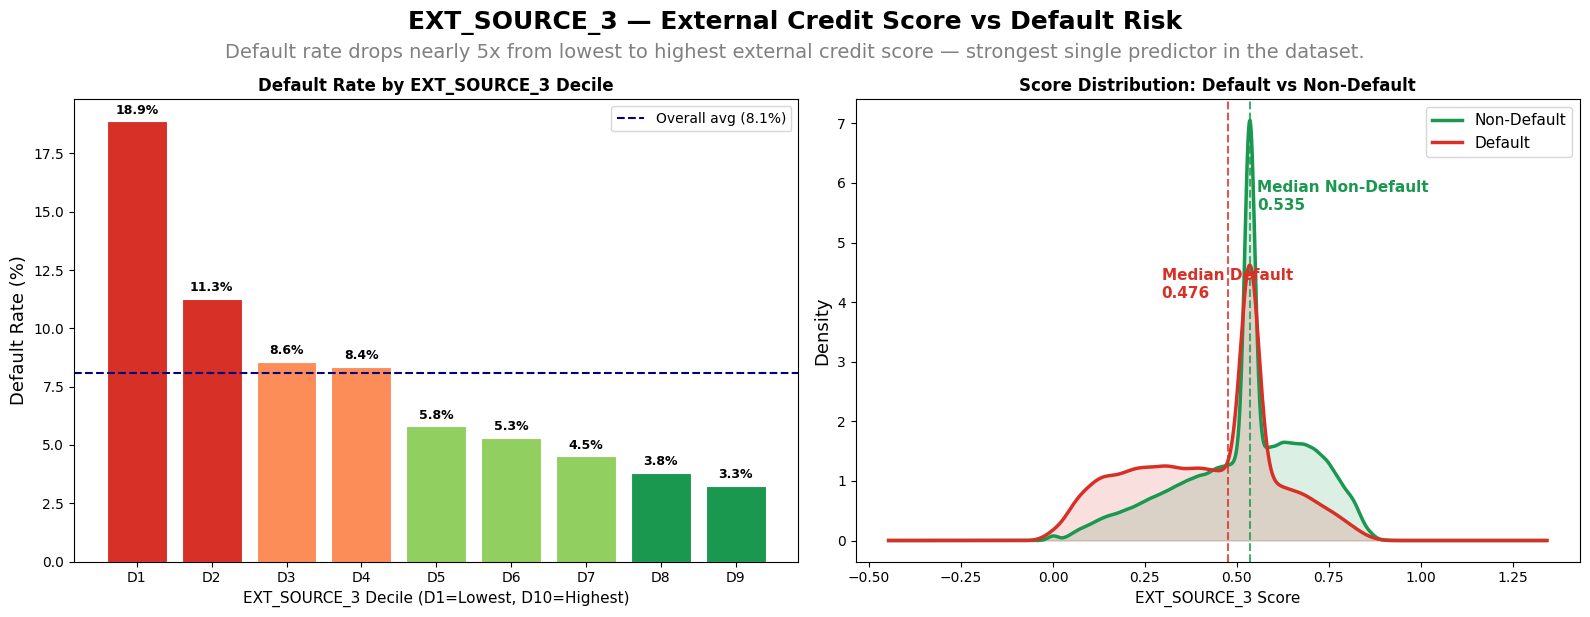

Default Rate by EXT_SOURCE_3 Decile:
bin_label  default_rate_pct  count
        0         18.877220  30852
        1         11.271314  31141
        2          8.558396  30473
        3          8.358004  91876
        4          5.801527    655
        5          5.315428  30308
        6          4.504245  31215
        7          3.789647  30425
        8          3.258523  30566

Median EXT_SOURCE_3 - Non-Default: 0.5353
Median EXT_SOURCE_3 - Default    : 0.4758


In [15]:
# Bin EXT_SOURCE_3 into deciles
df['EXT_SOURCE_3_BIN'] = pd.qcut(df['EXT_SOURCE_3'], q=10, duplicates='drop', labels=False)

# Calculate default rate per bin
ext3_default = df.groupby('EXT_SOURCE_3_BIN', observed=True).agg(
    default_rate=('TARGET', 'mean'),
    count=('TARGET', 'count')
).reset_index()
ext3_default['default_rate_pct'] = ext3_default['default_rate'] * 100
ext3_default['bin_label'] = ext3_default['EXT_SOURCE_3_BIN'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('EXT_SOURCE_3 — External Credit Score vs Default Risk',
             fontsize=18, fontweight='bold', y=1.02)
fig.text(0.5, 0.94,
         'Default rate drops nearly 5x from lowest to highest external credit score — strongest single predictor in the dataset.',
         ha='center', fontsize=14, color='gray')

# Plot 1: Default rate per bin
colors = ['#d73027' if r > 10 else '#fc8d59' if r > 8 else '#fee090' if r > 6 else '#91cf60' if r > 4 else '#1a9850'
          for r in ext3_default['default_rate_pct']]
bars = axes[0].bar(range(len(ext3_default)), ext3_default['default_rate_pct'],
                   color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_xticks(range(len(ext3_default)))
axes[0].set_xticklabels([f'D{i+1}' for i in range(len(ext3_default))], fontsize=10)
axes[0].set_xlabel('EXT_SOURCE_3 Decile (D1=Lowest, D10=Highest)', fontsize=11)
axes[0].set_ylabel('Default Rate (%)', fontsize=13)
axes[0].set_title('Default Rate by EXT_SOURCE_3 Decile', fontsize=12, fontweight='bold')
axes[0].axhline(y=df['TARGET'].mean() * 100, color='navy', linestyle='--', linewidth=1.5,
                label=f'Overall avg ({df["TARGET"].mean()*100:.1f}%)')
axes[0].legend()
for bar, val in zip(bars, ext3_default['default_rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: KDE by TARGET
ax2 = axes[1]

# Count Median 
med_nondefault = df[df['TARGET'] == 0]['EXT_SOURCE_3'].median()
med_default    = df[df['TARGET'] == 1]['EXT_SOURCE_3'].median()

# KDE lines
df[df['TARGET'] == 0]['EXT_SOURCE_3'].plot.kde(ax=ax2, color='#1a9850', linewidth=2.5, label='Non-Default')
df[df['TARGET'] == 1]['EXT_SOURCE_3'].plot.kde(ax=ax2, color='#d73027', linewidth=2.5, label='Default')

# Fill under curves
ax2.fill_between(ax2.lines[0].get_xdata(), ax2.lines[0].get_ydata(), alpha=0.15, color='#1a9850')
ax2.fill_between(ax2.lines[1].get_xdata(), ax2.lines[1].get_ydata(), alpha=0.15, color='#d73027')

# Median lines
ax2.axvline(x=med_nondefault, color='#1a9850', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.axvline(x=med_default,    color='#d73027', linestyle='--', linewidth=1.5, alpha=0.8)

# Median labels in Line
ax2.text(med_nondefault + 0.02, ax2.get_ylim()[1] * 0.75,
         f'Median Non-Default\n{med_nondefault:.3f}',
         color='#1a9850', fontsize=11, fontweight='bold')
ax2.text(med_default - 0.18, ax2.get_ylim()[1] * 0.55,
         f'Median Default\n{med_default:.3f}',
         color='#d73027', fontsize=11, fontweight='bold')

ax2.set_xlabel('EXT_SOURCE_3 Score', fontsize=11)
ax2.set_ylabel('Density', fontsize=13)
ax2.set_title('Score Distribution: Default vs Non-Default', fontsize=12, fontweight='bold')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Print summary
print("Default Rate by EXT_SOURCE_3 Decile:")
print(ext3_default[['bin_label', 'default_rate_pct', 'count']].to_string(index=False))
print(f"\nMedian EXT_SOURCE_3 - Non-Default: {med_nondefault:.4f}")
print(f"Median EXT_SOURCE_3 - Default    : {med_default:.4f}")

In [16]:
# Cek distribusi EXT_SOURCE_3
print(f"Min  : {df['EXT_SOURCE_3'].min():.4f}")
print(f"Max  : {df['EXT_SOURCE_3'].max():.4f}")
print(f"Top 10 most common values:")
print(df['EXT_SOURCE_3'].value_counts().head(10))

Min  : 0.0005
Max  : 0.8960
Top 10 most common values:
EXT_SOURCE_3
0.535276    61751
0.746300     1460
0.713631     1315
0.694093     1276
0.670652     1191
0.652897     1154
0.581484     1141
0.689479     1138
0.595456     1136
0.554947     1132
Name: count, dtype: int64


In [17]:
# Identifikasi median value (imputed)
ext3_median = df['EXT_SOURCE_3'].median()
print(f"EXT_SOURCE_3 median (imputed value): {ext3_median:.6f}")
print(f"Count of imputed values: {(df['EXT_SOURCE_3'] == ext3_median).sum():,}")
print(f"Total non-imputed: {(df['EXT_SOURCE_3'] != ext3_median).sum():,}")

# Filter hanya original values (non-imputed)
df_ext3_original = df[df['EXT_SOURCE_3'] != ext3_median].copy()
df_ext3_imputed  = df[df['EXT_SOURCE_3'] == ext3_median].copy()

print(f"\nOriginal values shape : {df_ext3_original.shape[0]:,}")
print(f"Imputed values shape  : {df_ext3_imputed.shape[0]:,}")
print(f"Default rate - original: {df_ext3_original['TARGET'].mean()*100:.2f}%")
print(f"Default rate - imputed : {df_ext3_imputed['TARGET'].mean()*100:.2f}%")

EXT_SOURCE_3 median (imputed value): 0.535276
Count of imputed values: 61,751
Total non-imputed: 245,760

Original values shape : 245,760
Imputed values shape  : 61,751
Default rate - original: 7.77%
Default rate - imputed : 9.26%


In [18]:
# Bin hanya original values
df_ext3_original['EXT_SOURCE_3_BIN'] = pd.qcut(
    df_ext3_original['EXT_SOURCE_3'], q=10, duplicates='drop', labels=False
)

# Default rate per bin
ext3_default = df_ext3_original.groupby('EXT_SOURCE_3_BIN', observed=True).agg(
    default_rate=('TARGET', 'mean'),
    count=('TARGET', 'count')
).reset_index()
ext3_default['default_rate_pct'] = ext3_default['default_rate'] * 100

# Tambahkan imputed sebagai bar terpisah
imputed_row = pd.DataFrame({
    'EXT_SOURCE_3_BIN': ['Imputed\n(Missing)'],
    'default_rate_pct': [df_ext3_imputed['TARGET'].mean() * 100],
    'count': [len(df_ext3_imputed)]
})

n_bins = len(ext3_default)
print(f"Bins terbentuk: {n_bins}")
print(ext3_default[['EXT_SOURCE_3_BIN', 'default_rate_pct', 'count']])
print(f"\nImputed default rate: {imputed_row['default_rate_pct'].values[0]:.2f}%")


Bins terbentuk: 10
   EXT_SOURCE_3_BIN  default_rate_pct  count
0                 0         20.003239  24701
1                 1         12.754607  24744
2                 2          9.527908  24402
3                 3          8.051980  24702
4                 4          6.195084  24697
5                 5          5.332094  24737
6                 6          4.744186  24725
7                 7          4.214993  24745
8                 8          3.543844  24211
9                 9          3.208001  24096

Imputed default rate: 9.26%


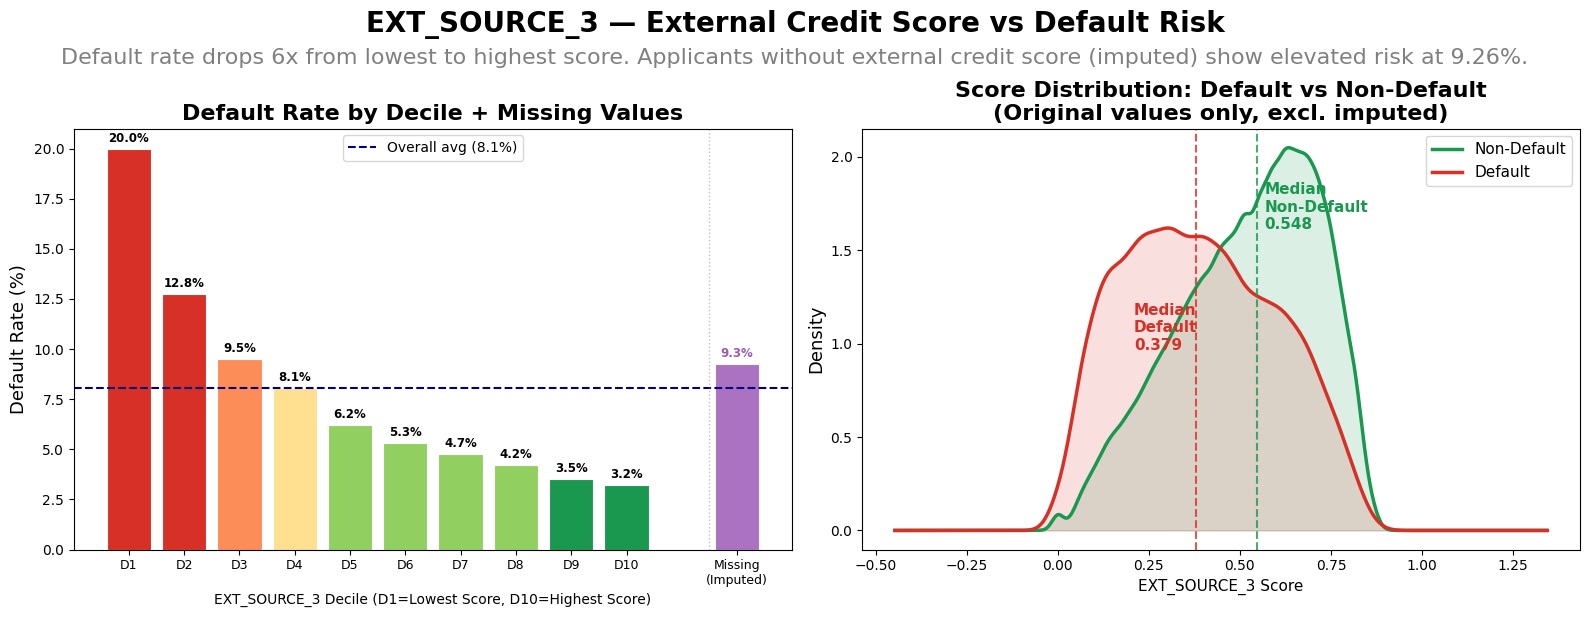

EXT_SOURCE_3 Key Stats:
Decile         Default Rate      Count
----------------------------------------
D1                   20.00%     24,701
D2                   12.75%     24,744
D3                    9.53%     24,402
D4                    8.05%     24,702
D5                    6.20%     24,697
D6                    5.33%     24,737
D7                    4.74%     24,725
D8                    4.21%     24,745
D9                    3.54%     24,211
D10                   3.21%     24,096
Missing               9.26%     61,751

Median Non-Default : 0.5478
Median Default     : 0.3791
Gap                : 0.1687


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('EXT_SOURCE_3 — External Credit Score vs Default Risk',
             fontsize=20, fontweight='bold', y=1.02)
fig.text(0.5, 0.93,
         'Default rate drops 6x from lowest to highest score. Applicants without external credit score (imputed) show elevated risk at 9.26%.',
         ha='center', fontsize=16, color='gray')

# ── Plot 1: Default rate per decile + imputed bar ──
colors_main = ['#d73027' if r > 12 else '#fc8d59' if r > 9 else
               '#fee090' if r > 7 else '#91cf60' if r > 4 else '#1a9850'
               for r in ext3_default['default_rate_pct']]

x_positions = list(range(10))
bars = axes[0].bar(x_positions, ext3_default['default_rate_pct'],
                   color=colors_main, edgecolor='white', linewidth=0.8)

# Imputed bar — posisi terpisah dengan gap
axes[0].bar(11, imputed_row['default_rate_pct'].values[0],
            color='#9b59b6', edgecolor='white', linewidth=0.8, alpha=0.85)

# Annotation per bar
for bar, val in zip(bars, ext3_default['default_rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# Annotation imputed bar
axes[0].text(11, imputed_row['default_rate_pct'].values[0] + 0.2,
            f'{imputed_row["default_rate_pct"].values[0]:.1f}%',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#9b59b6')

# Overall avg line
overall_avg = df['TARGET'].mean() * 100
axes[0].axhline(y=overall_avg, color='navy', linestyle='--', linewidth=1.5,
                label=f'Overall avg ({overall_avg:.1f}%)')

# X labels
axes[0].set_xticks(list(range(10)) + [11])
axes[0].set_xticklabels([f'D{i+1}' for i in range(10)] + ['Missing\n(Imputed)'], fontsize=9)
axes[0].set_xlabel('EXT_SOURCE_3 Decile (D1=Lowest Score, D10=Highest Score)', fontsize=10)
axes[0].set_ylabel('Default Rate (%)', fontsize=13)
axes[0].set_title('Default Rate by Decile + Missing Values', fontsize=16, fontweight='bold')
axes[0].legend()

# Separator line antara deciles dan imputed
axes[0].axvline(x=10.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)

# ── Plot 2: KDE by TARGET (original values only) ──
ax2 = axes[1]

med_nondefault = df_ext3_original[df_ext3_original['TARGET'] == 0]['EXT_SOURCE_3'].median()
med_default    = df_ext3_original[df_ext3_original['TARGET'] == 1]['EXT_SOURCE_3'].median()

df_ext3_original[df_ext3_original['TARGET'] == 0]['EXT_SOURCE_3'].plot.kde(
    ax=ax2, color='#1a9850', linewidth=2.5, label='Non-Default')
df_ext3_original[df_ext3_original['TARGET'] == 1]['EXT_SOURCE_3'].plot.kde(
    ax=ax2, color='#d73027', linewidth=2.5, label='Default')

ax2.fill_between(ax2.lines[0].get_xdata(), ax2.lines[0].get_ydata(), alpha=0.15, color='#1a9850')
ax2.fill_between(ax2.lines[1].get_xdata(), ax2.lines[1].get_ydata(), alpha=0.15, color='#d73027')

# Median lines
ax2.axvline(x=med_nondefault, color='#1a9850', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.axvline(x=med_default,    color='#d73027', linestyle='--', linewidth=1.5, alpha=0.8)

# Dapatkan ylim setelah plot
ymax = ax2.get_ylim()[1]

# Median labels — posisi vertikal berbeda agar tidak overlap
ax2.text(med_nondefault + 0.02, ymax * 0.75,
         f'Median\nNon-Default\n{med_nondefault:.3f}',
         color='#1a9850', fontsize=11, fontweight='bold')
ax2.text(med_default - 0.17, ymax * 0.45,
         f'Median\nDefault\n{med_default:.3f}',
         color='#d73027', fontsize=11, fontweight='bold')

ax2.set_xlabel('EXT_SOURCE_3 Score', fontsize=11)
ax2.set_ylabel('Density', fontsize=13)
ax2.set_title('Score Distribution: Default vs Non-Default\n(Original values only, excl. imputed)',
              fontsize=16, fontweight='bold')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("=" * 55)
print("EXT_SOURCE_3 Key Stats:")
print("=" * 55)
print(f"{'Decile':<12} {'Default Rate':>14} {'Count':>10}")
print("-" * 40)
for _, row in ext3_default.iterrows():
    print(f"D{int(row['EXT_SOURCE_3_BIN'])+1:<11} {row['default_rate_pct']:>13.2f}% {int(row['count']):>10,}")
print(f"{'Missing':<12} {imputed_row['default_rate_pct'].values[0]:>13.2f}% {int(imputed_row['count'].values[0]):>10,}")
print(f"\nMedian Non-Default : {med_nondefault:.4f}")
print(f"Median Default     : {med_default:.4f}")
print(f"Gap                : {med_nondefault - med_default:.4f}")